In [12]:
# ------------------- Import packages --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from datetime import datetime
import locale
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')

'en_US.UTF-8'

In [13]:
# ------------------ - Load results ------------------
df_addressable_results = pl.read_csv("Results/gini_addressable_results.csv")
df_artemis_results = pl.read_csv("Results/gini_artemis_results.csv")
df_addressable_results = df_addressable_results.with_columns(pl.col("Date").str.to_datetime().cast(pl.Date))
df_artemis_results = df_artemis_results.with_columns(pl.col("Date").str.to_datetime().cast(pl.Date))

In [14]:
# ------------------ 01 - Function: january xticks ------------------
def set_january_xticks(dates):
    jan_dates = [d for d in dates if d.month == 1]
    plt.xticks(jan_dates, [d.strftime('%b %Y') for d in jan_dates])


# ------------------ 02 - Function: add event lines ------------------
def add_event_lines(ax=None):
    """
    Adds vertical dashed lines for specific dates on a plot.
    The default dates are: 
    2020-12-01, 2021-08-05, 2021-10-27, 2022-09-15, 2023-04-12, 2024-03-13, 2024-07-23
    """
    if ax is None:
        ax = plt.gca()
    
    event_dates = ["2020-12-01", "2021-08-05", "2021-10-27", 
        "2022-09-15", "2023-04-12", "2024-03-13", "2024-07-23"]
    
    event_dates = [datetime.strptime(date, "%Y-%m-%d") for date in event_dates]
    
    for date in event_dates:
        ax.axvline(x=date, color='gray', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

# ------------------ 03 - Style for Plots ------------------
plt.style.use('tableau-colorblind10')
def set_plot_style():
    plt.rcParams.update({"axes.labelsize": 20,"xtick.labelsize": 18,"ytick.labelsize": 18,"legend.fontsize": 18,"legend.title_fontsize": 20,"axes.titlesize": 22})
set_plot_style()

# --------- 04 - Ranking ---------
rankings = [380, 1600]


# Figure 1

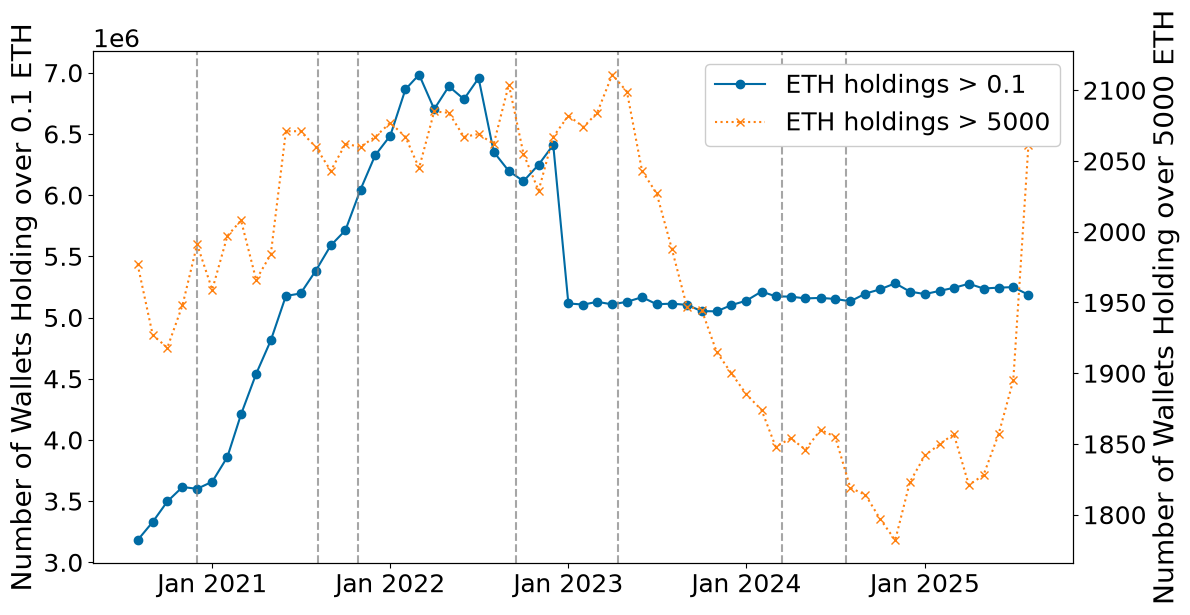

In [15]:
# ----------------------------- Number of Wallets Holding More Than ETH Thresholds -----------------------
df_counts = pd.read_csv("Results/wallet_num_results.csv")
df_counts["Date"] = pd.to_datetime(df_counts["Date"])

plt.style.use('tableau-colorblind10')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
i_left = 0.1
i_right = 5000

# Plot LEFT 
ax1.plot(df_counts["Date"].to_list(), df_counts["Count_Left"].to_list(), marker='o', linestyle='-', color=colors[0], label=f'ETH holdings > {i_left}')
ax1.set_ylabel(f"Number of Wallets Holding over {i_left} ETH")

# Plot RIGHT 
ax2.plot(df_counts["Date"].to_list(), df_counts["Count_Right"].to_list(), marker='x', linestyle=':', color=colors[1], label=f'ETH holdings > {i_right}')
ax2.set_ylabel(f"Number of Wallets Holding over {i_right} ETH")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
add_event_lines(ax=ax1)
leg = ax2.legend(lines1 + lines2, labels1 + labels2,loc="upper right",frameon=True,facecolor="white",framealpha=1)
leg.set_zorder(1000)
set_january_xticks(df_addressable_results["Date"]) 
plt.tight_layout()
plt.show()

# Figure 2

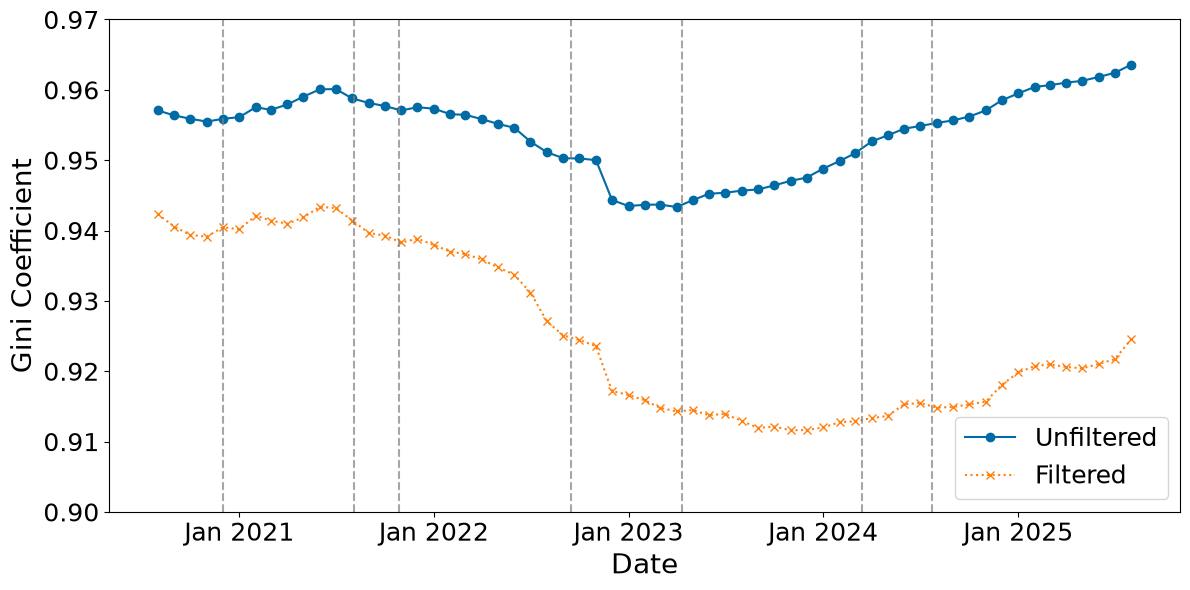

In [16]:
# --------------- Filtered & Unfiltered Gini (Top 1M Wallets) --------------------

plt.figure(figsize=(12, 6))
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results['Gini_ETH_Unfiltered'].to_list(),marker='o', linestyle='-', label="Unfiltered")
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results['Gini_ETH_Filtered'].to_list(),marker='x', linestyle=':', label="Filtered")
plt.xlabel("Date")
plt.ylabel("Gini Coefficient")
#plt.title("Gini Coefficient 2020-2025 (Top 1M Wallets)")
plt.legend()
plt.ylim(0.9,0.97)
plt.tight_layout()
add_event_lines()
set_january_xticks(df_addressable_results["Date"])
plt.show()


# Figure 3

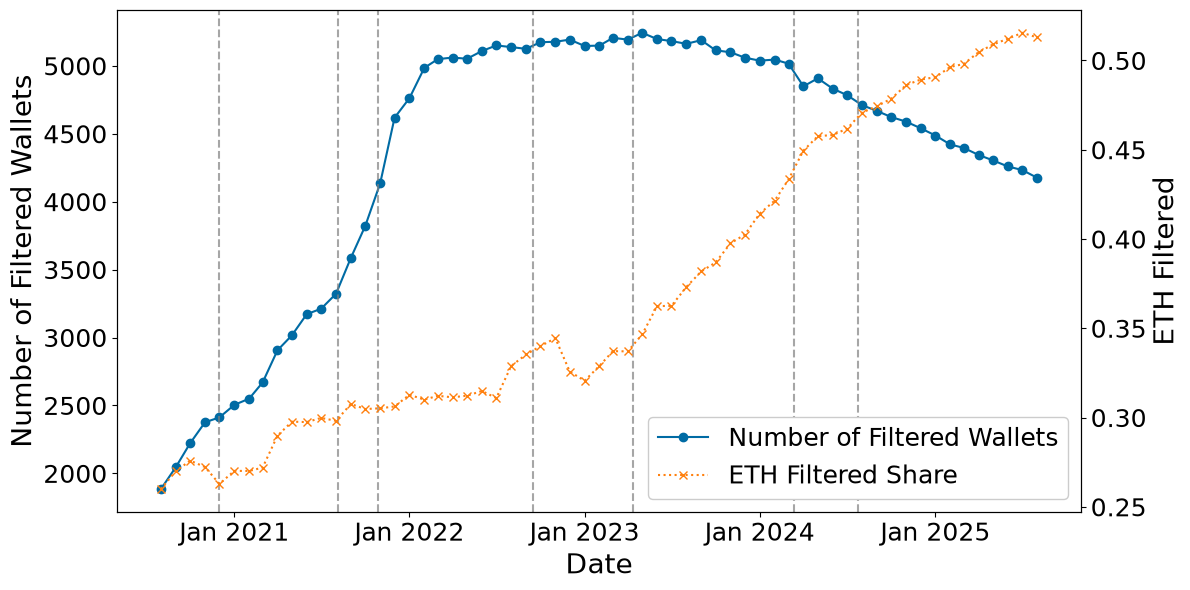

In [17]:
# ---------------- OVER 0.1 ETH - Number of wallets filtered & percentage of ETH filtered ------------------------

filtering_01_ETH_results = pd.read_csv('Results/filtering_01_ETH_results.csv')
x = filtering_01_ETH_results['Date'].to_list()
num_wallets_filtered_list = filtering_01_ETH_results['Num_Wallets_Filtered'].to_list()
eth_filtered_pct_list = filtering_01_ETH_results['ETH_Filtered_Pct'].to_list()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
x = df_artemis_results["Date"].to_list()

# Left axis: number of wallets filtered
ax1.plot(x,num_wallets_filtered_list,marker='o',linestyle='-',color=colors[0],label="Number of Filtered Wallets")
ax1.set_ylabel("Number of Filtered Wallets")

# Right axis: ETH percentage filtered
ax2.plot(x,eth_filtered_pct_list,marker='x',linestyle=':',color=colors[1],label="ETH Filtered Share")
ax2.set_ylabel("ETH Filtered")

# X axis
ax1.set_xlabel("Date")
set_january_xticks(df_addressable_results["Date"])
add_event_lines(ax1)

# Legend (combined)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right",  frameon=True,
    facecolor="white",framealpha=1)
leg.set_zorder(1000)

plt.tight_layout()
plt.show()

# Figure 4 & Table 1

\begin{tabular}{llllll}
\toprule
0 & 1 & 2 & 3 & 4 & 5 \\
\midrule
0.957 & 0.634 & 0.540 & 0.475 & 0.422 & 0.381 \\
0.959 & 0.577 & 0.485 & 0.421 & 0.370 & 0.330 \\
0.951 & 0.550 & 0.457 & 0.394 & 0.345 & 0.306 \\
0.946 & 0.530 & 0.438 & 0.378 & 0.331 & 0.293 \\
0.955 & 0.528 & 0.438 & 0.378 & 0.332 & 0.294 \\
0.964 & 0.530 & 0.442 & 0.381 & 0.334 & 0.297 \\
\bottomrule
\end{tabular}



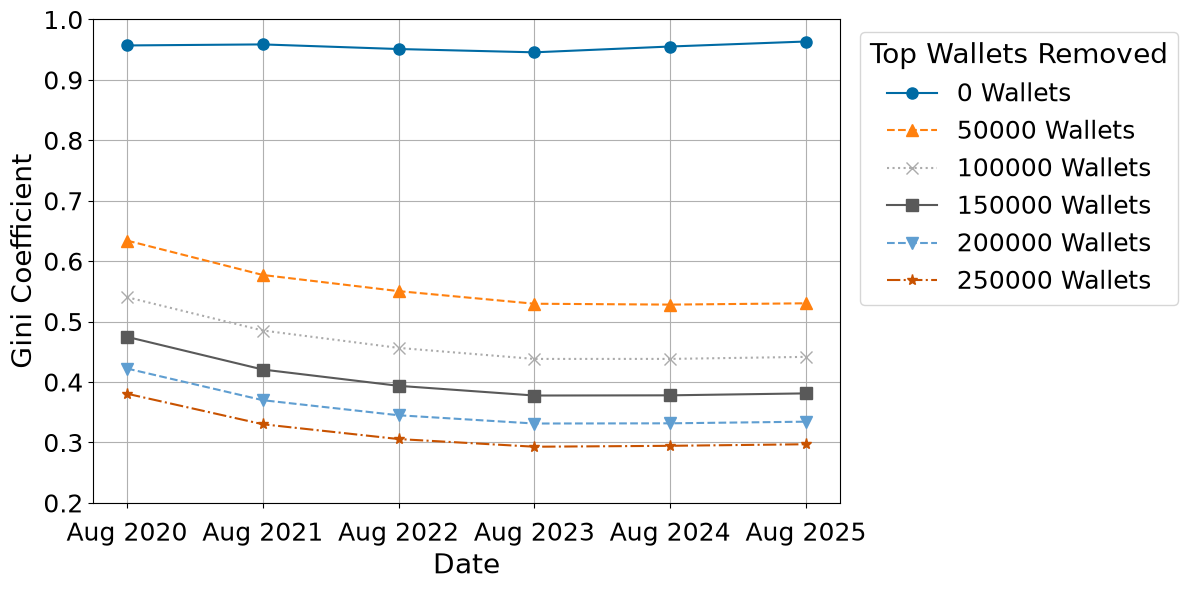

In [18]:
# -----------------  Ranking Table ---------------------------
ranking_df = pd.read_csv('Results/gini_ranking_results.csv', index_col=0)
latex_table = ranking_df.to_latex(index=False,escape=False,column_format="l" * len(ranking_df.columns),float_format="%.3f")
print(latex_table)

# -----------------  Ranking plot (Top 1M Wallets) ---------------------------
cut_points = [0, 50000, 100000, 150000, 200000, 250000]
ranking_df.columns = cut_points
ranking_df.index = pd.to_datetime(ranking_df.index)
ranking_df.index = ranking_df.index.strftime('%b %Y')
line_styles = ['-', '--', ':', '-', '--', '-.']
markers = ['o', '^', 'x', 's', 'v', '*']

plt.figure(figsize=(12, 6))
for (col_name, col_data), ls, mk in zip(ranking_df.items(), line_styles, markers):
    plt.plot(ranking_df.index, col_data, marker=mk, linestyle=ls, label=f"{col_name} Wallets", markersize=8)
plt.tick_params(axis='x', pad=10)
plt.xlabel("Date") 
plt.ylabel("Gini Coefficient")
plt.ylim(0.2, 1)
plt.legend(title="Top Wallets Removed", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Figure 5

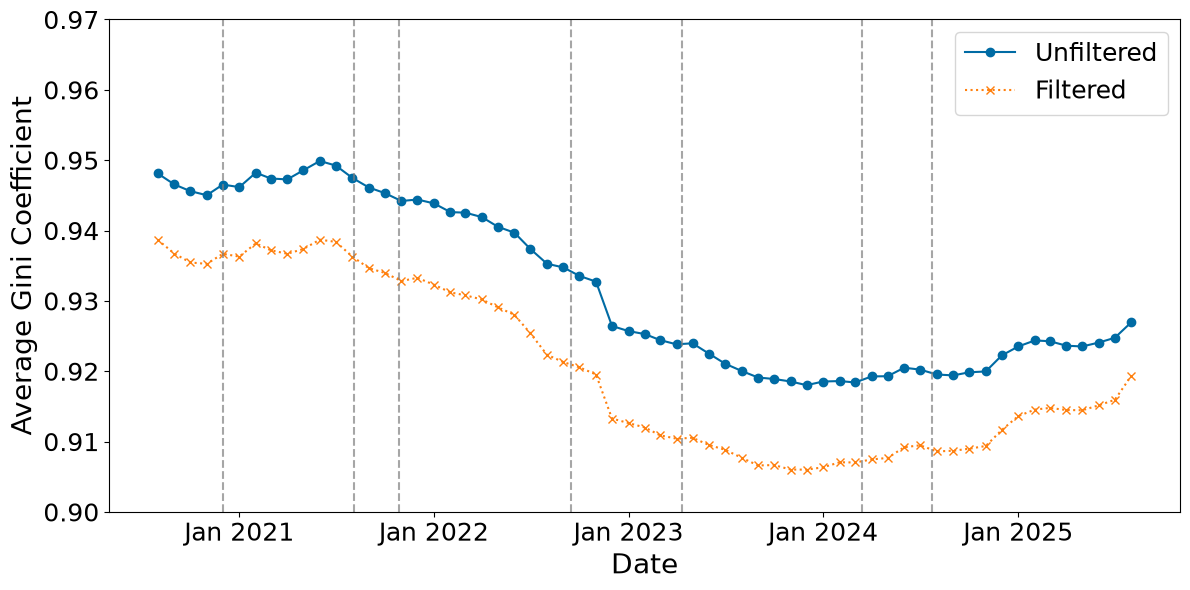

In [19]:
# --------------------  Random Gini (Top 1M Wallets) ---------------------------
plt.figure(figsize=(12, 6))
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results['RandomMean_ETH'].to_list(),marker='o', linestyle='-', label="Unfiltered")
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results['RandomMean_ETH_F'].to_list(),marker='x', linestyle=':', label="Filtered")
plt.xlabel("Date")
plt.ylabel("Average Gini Coefficient")
#plt.title("Random Gini (Top 1M Wallets)")
plt.legend()
plt.ylim(0.9,0.97)
plt.tight_layout()
add_event_lines()
set_january_xticks(df_addressable_results["Date"])
plt.show()


# Robustness Check Plots: Figrues 8-10, 13-14

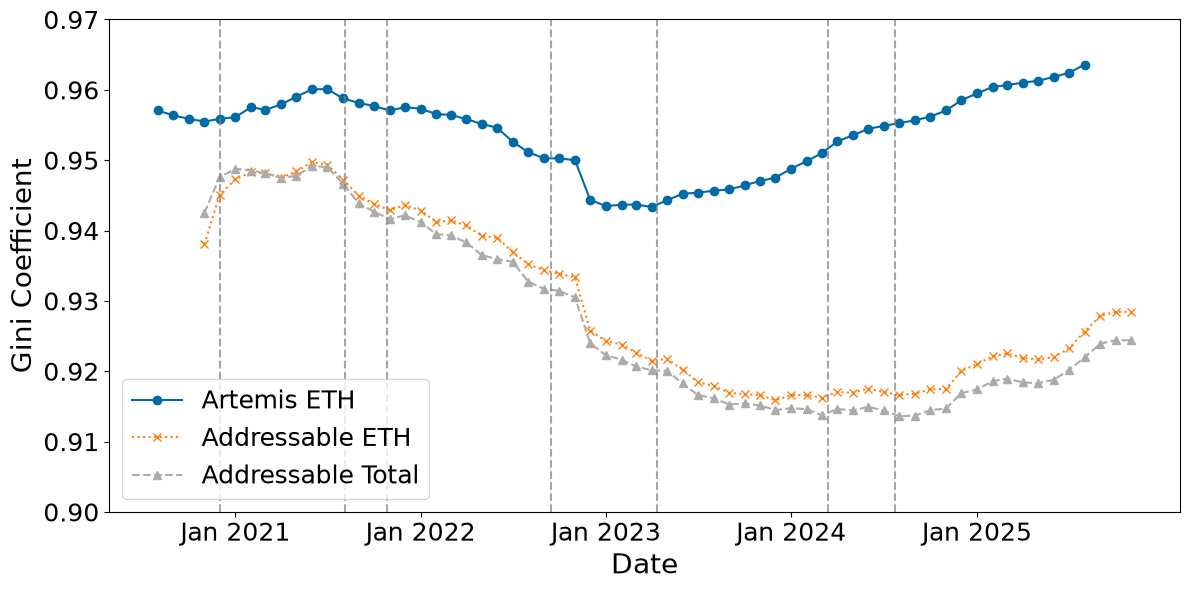

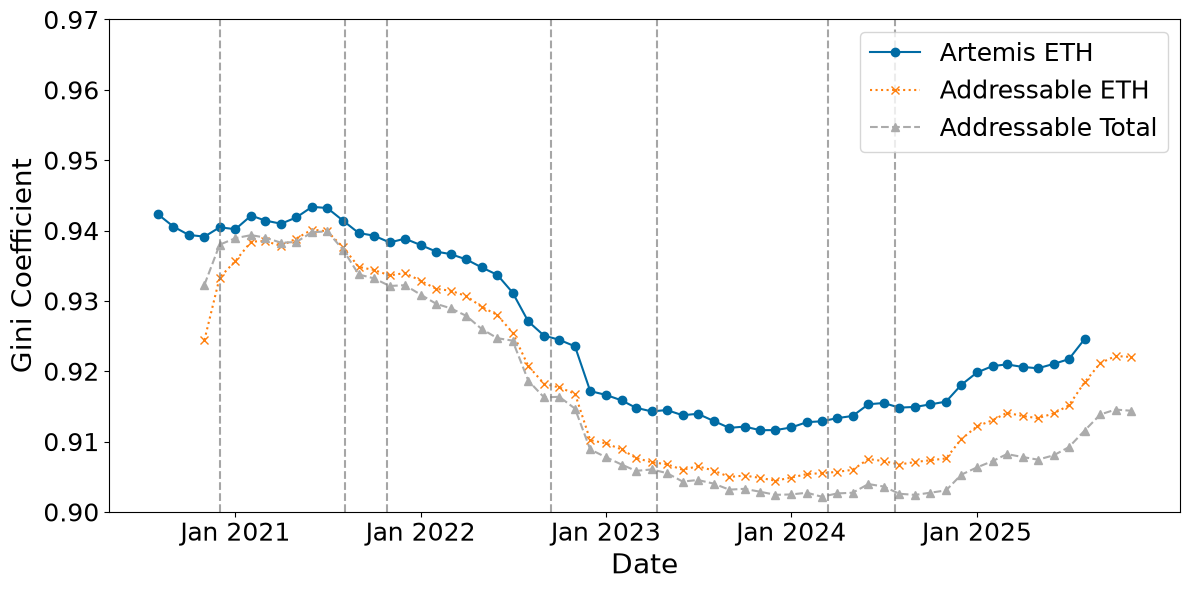

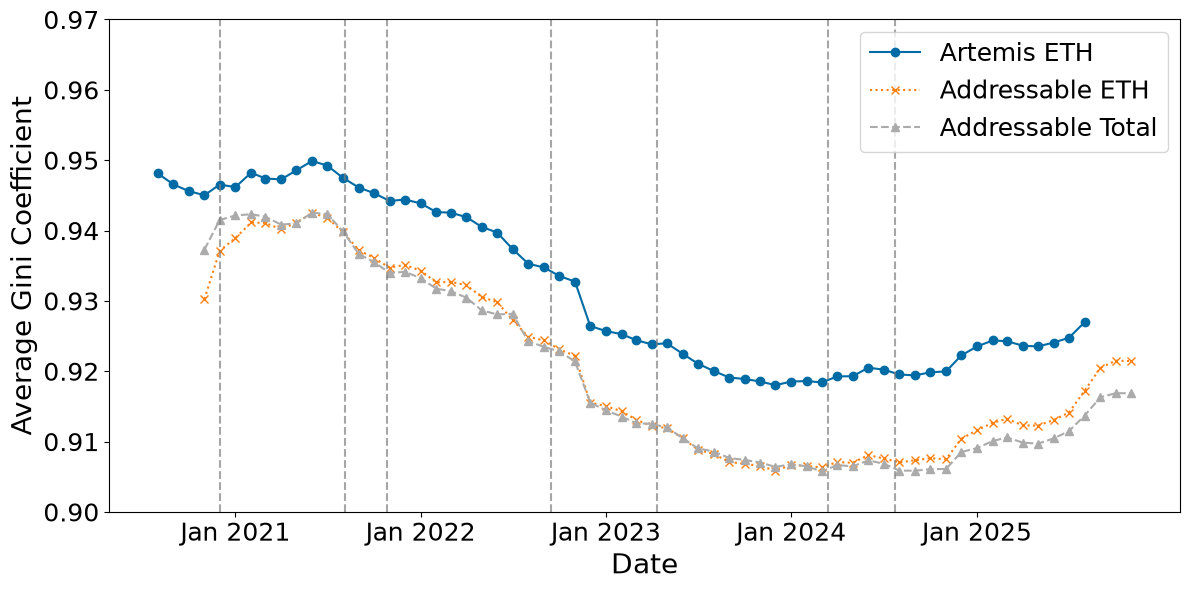

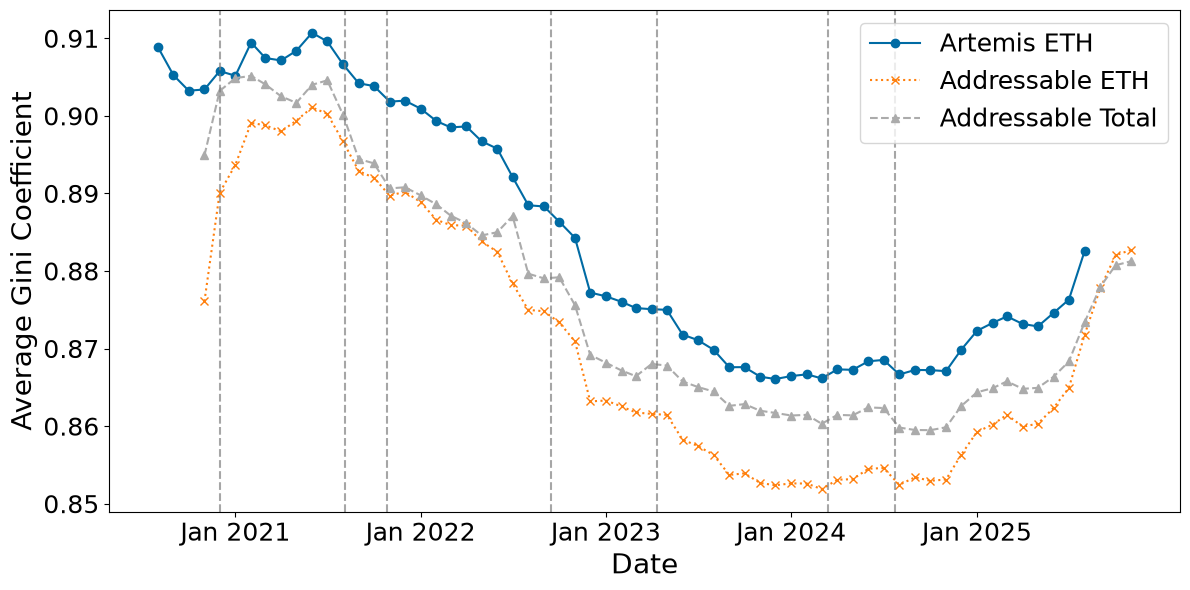

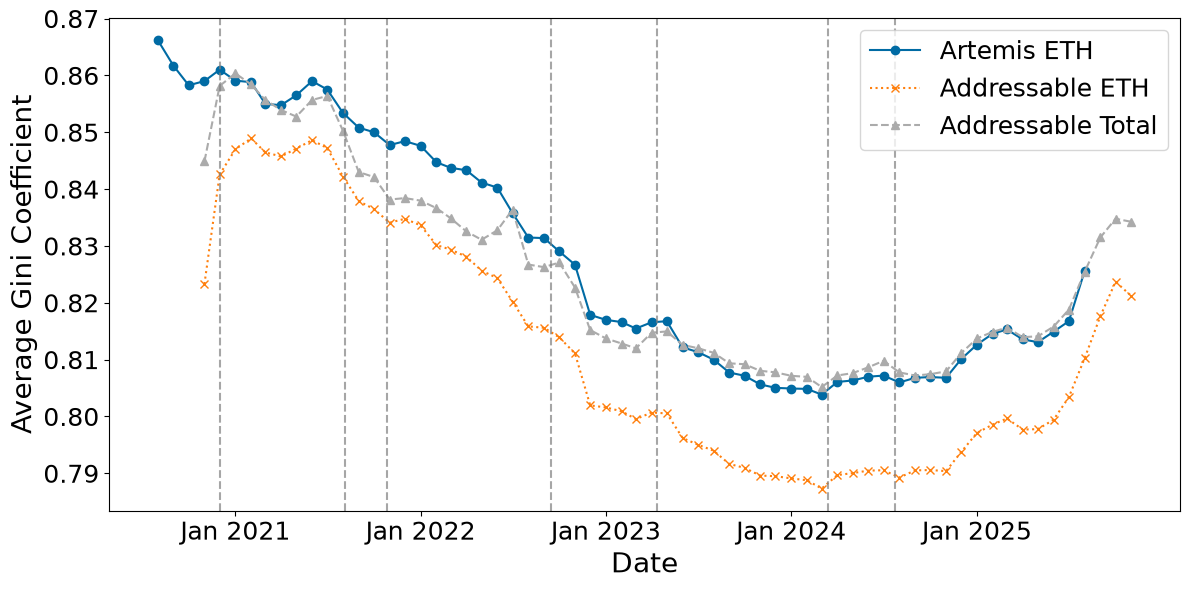

In [20]:
# ------------------------------- Robustness Check Plots -----------------------------------
# ------------- 1. Robustness Check: Unfiltered Gini Over Time -------------
plt.figure(figsize=(12, 6))
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results['Gini_ETH_Unfiltered'].to_list(),marker='o', linestyle='-', label="Artemis ETH")
plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results["Gini_ETH_Unfiltered"].to_list(),marker='x', linestyle=':',label="Addressable ETH")
plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results["Gini_Total_Unfiltered"].to_list(),marker='^', linestyle='--', label="Addressable Total")
plt.xlabel("Date")
plt.ylabel("Gini Coefficient")
#plt.title("Gini Coefficient Over Time (Top 1M Wallets, Unfiltered)")
plt.legend()
plt.ylim(0.9,0.97)
add_event_lines()
set_january_xticks(df_addressable_results["Date"])
plt.tight_layout()

# ------------- 2. Robustness Check: Filtered Gini Over Time -------------
plt.figure(figsize=(12, 6))
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results['Gini_ETH_Filtered'].to_list(),marker='o', linestyle='-', label="Artemis ETH")
plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results["Gini_ETH_Filtered"].to_list(),marker='x', linestyle=':', label="Addressable ETH")
plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results["Gini_Total_Filtered"].to_list(),marker='^', linestyle='--', label="Addressable Total")
plt.xlabel("Date")
plt.ylabel("Gini Coefficient")
plt.ylim(0.9,0.97)
#plt.title("Gini Coefficient Over Time (Top 1M Wallets, Filtered)")
plt.legend()
add_event_lines()
set_january_xticks(df_addressable_results["Date"])
plt.tight_layout()

# ------------------ 3. Robustness Check: Random Gini, Unfiltered ------------------
plt.figure(figsize=(12,6))
plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results["RandomMean_ETH"].to_list(),marker='o', linestyle='-', label="Artemis ETH")
plt.plot(df_addressable_results["Date"].to_list(), df_addressable_results["RandomMean_ETH"].to_list(),marker='x', linestyle=':', label="Addressable ETH")
plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results["RandomMean_Total"].to_list(),marker='^', linestyle='--', label="Addressable Total")
plt.xlabel("Date")
plt.ylabel("Average Gini Coefficient")
plt.ylim(0.9,0.97)
#plt.title("Random Gini (Top 1M Wallets, Unfiltered)")
plt.legend()
set_january_xticks(df_addressable_results["Date"])
add_event_lines()
plt.tight_layout()
plt.show()

# ----------------------- 4. Robustness Check: Ranking Trend  ------------------------------
# Loop over each ranking to create a separate plot
for rank in rankings:
    plt.figure(figsize=(12,6))
    
    # Artemis ETH column
    artemis_col = f"Ranking_{rank}_ETH"
    plt.plot(df_artemis_results["Date"].to_list(),df_artemis_results[artemis_col].to_list(),
        marker='o', linestyle='-', label="Artemis ETH")
    
    # Addressable ETH column
    addressable_eth_col = f"Ranking_{rank}_ETH"
    plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results[addressable_eth_col].to_list(),
        marker='x', linestyle=':', label='Addressable ETH')
    
    # Addressable Total column
    addressable_total_col = f"Ranking_{rank}_Total"
    plt.plot(df_addressable_results["Date"].to_list(),df_addressable_results[addressable_total_col].to_list(),
        marker='^', linestyle='--', label='Addressable Total')
    
    plt.xlabel("Date")
    plt.ylabel("Average Gini Coefficient")
    #plt.title(f"Ranking {rank} Gini (Top 1M Wallets, Unfiltered)")
    plt.legend()
    set_january_xticks(df_addressable_results["Date"])
    add_event_lines()
    plt.tight_layout()
    plt.show()




# Robustness Check Figures 11-12


=== Artemis (ETH) ===
Average number of filtered wallets: 1,657.61
Average filtered ETH share (fraction): 0.3761


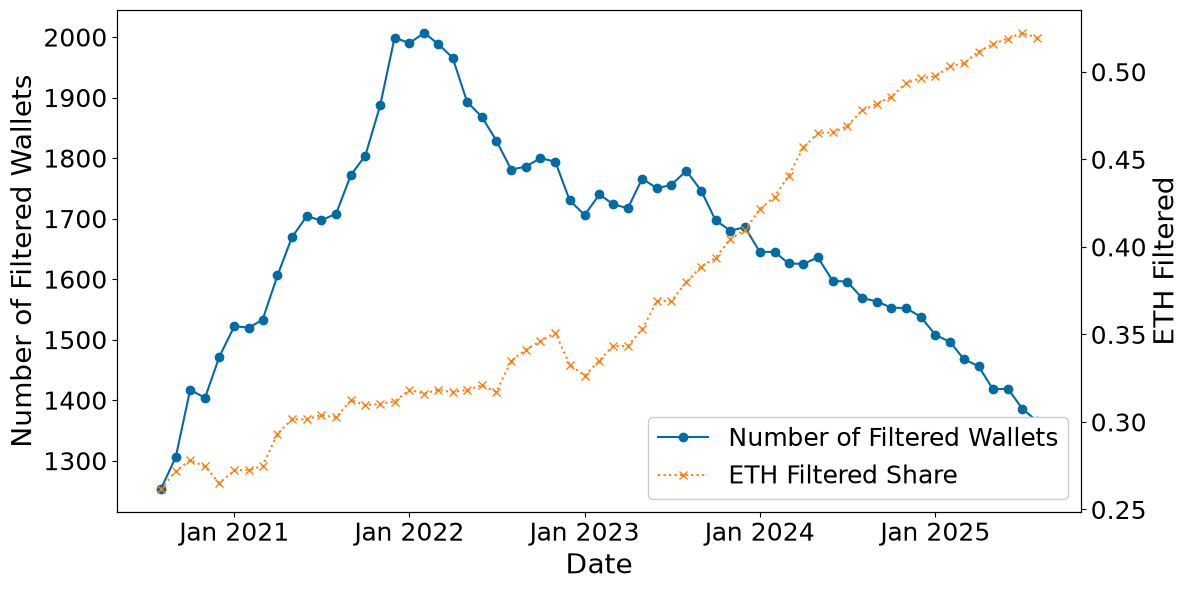

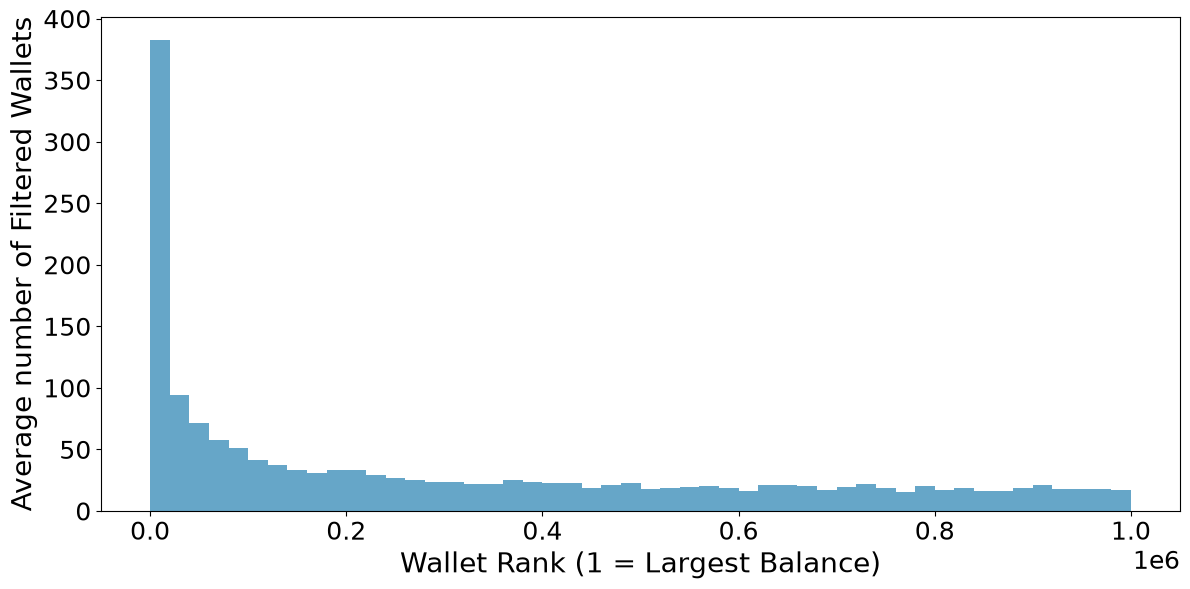

In [21]:
# Figure 11
# TOP 1M - Filtered Wallets Plots 
plt.style.use('tableau-colorblind10')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')

for name, df, asset in [("Artemis", df_artemis_results, "ETH")]:

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    #  Averages 
    avg_wallets_filtered = df["Filtered_Wallets_Number"].mean()
    avg_eth_filtered = df["ETH_Filtered_PCT"].mean()

    print(f"\n=== {name} ({asset}) ===")
    print(f"Average number of filtered wallets: {avg_wallets_filtered:,.2f}")
    print(f"Average filtered ETH share (fraction): {avg_eth_filtered:.4f}")

    #  Left axis: wallets 
    ax1.plot(df["Date"].to_list(),df["Filtered_Wallets_Number"],marker='o',
        color=colors[0],label="Number of Filtered Wallets")
    ax1.set_ylabel("Number of Filtered Wallets")

    #  Right axis: ETH share 
    ax2.plot(df["Date"].to_list(),df["ETH_Filtered_PCT"],
        marker='x',linestyle=':',color=colors[1],label="ETH Filtered Share")
    ax2.set_ylabel("ETH Filtered")

    #  X axis 
    ax1.set_xlabel("Date")
    set_january_xticks(df["Date"])

    #  Combined legend 
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2,labels1 + labels2,loc="lower right", frameon=True,
         facecolor="white",framealpha=1)
    plt.tight_layout()
    plt.show()


# Figure 12
#  Filtered Wallets Plots 
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')
plt.style.use('tableau-colorblind10')
datasets = [("Artemis", df_artemis_results, "ETH"),]

# Loop over datasets
for label, df, balance_type in datasets:
    
    # Define columns dynamically
    if label == "Artemis":
        wallets_col = "Filtered_Wallets_Number"
        pct_col = "ETH_Filtered_PCT"
        hist_col = "Filtered_Row_Hist"
        y_label = "ETH Removed (%)"

    #  Average Histogram 
    hist_list = [np.fromstring(r, sep=',', dtype=float) for r in df[hist_col]]
    hist_array = np.vstack(hist_list)
    avg_hist = hist_array.mean(axis=0)
    
    num_bins = len(avg_hist)
    max_rank = 1_000_000
    bin_edges = np.linspace(0, max_rank, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    plt.figure(figsize=(12, 6))
    plt.bar(bin_centers, avg_hist, width=(bin_edges[1]-bin_edges[0]), alpha=0.6)
    #for i in range(len(avg_hist)):
    #    plt.text(bin_centers[i],avg_hist[i],f"{int(round(avg_hist[i]))}",  ha='center', va='bottom', fontsize=8)
    plt.xlabel("Wallet Rank (1 = Largest Balance)" if balance_type=="ETH" else "Row (Total Rank, 1 = largest balance)")
    plt.ylabel("Average number of Filtered Wallets")
    #plt.title(f"Average Distribution of Filtered Wallets ({label} - {balance_type})", fontsize=14)
    plt.tight_layout()
    plt.show()

# Robustness Check: Tables 2-3

In [22]:
# ------------------- Corr Matrix -------------------
model_configs = [
    (df_artemis_results, "Gini_ETH_Unfiltered", "No method was applied", "Artemis ETH"),
    (df_addressable_results, "Gini_ETH_Unfiltered", "No method was applied", "Addressable ETH"),
    (df_addressable_results, "Gini_Total_Unfiltered", "No method was applied", "Addressable Total"),
    (df_artemis_results, "Gini_ETH_Filtered", "Filtering", "Artemis ETH"),
    (df_addressable_results, "Gini_ETH_Filtered", "Filtering", "Addressable ETH"),
    (df_addressable_results, "Gini_Total_Filtered", "Filtering", "Addressable Total"),
    (df_artemis_results, "RandomMean_ETH", "Random Trend", "Artemis ETH"),
    (df_addressable_results, "RandomMean_ETH", "Random Trend", "Addressable ETH"),
    (df_addressable_results, "RandomMean_Total", "Random Trend", "Addressable Total")
]

for rank in rankings:
    model_configs.extend([
        (df_artemis_results, f"Ranking_{rank}_ETH", f"Ranking Trend ({rank})", "Artemis ETH"),
        (df_addressable_results, f"Ranking_{rank}_ETH", f"Ranking Trend ({rank})", "Addressable ETH"),
        (df_addressable_results, f"Ranking_{rank}_Total", f"Ranking Trend ({rank})", "Addressable Total")
    ])

df_list = []
mapping_data = []

for i, (df, col, method, dataset) in enumerate(model_configs, start=1):
    model_id = f"M{i}" 
    df_list.append(df.select(["Date", col]).rename({col: model_id}))
    mapping_data.append((model_id, method, dataset))

df_gini_combined = df_list[0]
for df in df_list[1:]:
    df_gini_combined = df_gini_combined.join(df, on="Date", how="inner")

corr_matrix = df_gini_combined.drop("Date").to_pandas().corr()


df_key = pd.DataFrame(mapping_data, columns=["Model", "Method", "Dataset"])
print("Table 1: Model Identification Key")
display(df_key.style.hide(axis='index').set_properties(**{
    'text-align': 'left', 
    'border': '1px solid #ddd',
    'padding': '4px 8px'
}))

# Half table
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
half_corr = corr_matrix.mask(mask)

print("\nTable 2: Correlation Matrix")
display(half_corr.style.format("{:.4f}", na_rep="").set_properties(**{
    'text-align': 'center',
    'border': '1px solid #ddd',
    'padding': '4px'
}))

# -------------------------------- LaTeX --------------------------------------

latex_key = df_key.to_latex(index=False, caption="Model Identification Key",label="tab:model_key",column_format="lll" )
print("--- LaTeX Code for Table 1 ---")
print(latex_key)

formatted_corr = half_corr.map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
latex_corr = formatted_corr.to_latex(float_format="%.2f",caption="Correlation Matrix",label="tab:corr_matrix")
print("\n--- LaTeX Code for Table 2 ---")
print(latex_corr)

Table 1: Model Identification Key


Model,Method,Dataset
M1,No method was applied,Artemis ETH
M2,No method was applied,Addressable ETH
M3,No method was applied,Addressable Total
M4,Filtering,Artemis ETH
M5,Filtering,Addressable ETH
M6,Filtering,Addressable Total
M7,Random Trend,Artemis ETH
M8,Random Trend,Addressable ETH
M9,Random Trend,Addressable Total
M10,Ranking Trend (380),Artemis ETH



Table 2: Correlation Matrix


,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14,M15
M1,1.0000,,,,,,,,,,,,,,
M2,0.4078,1.0000,,,,,,,,,,,,,
M3,0.3740,0.9954,1.0000,,,,,,,,,,,,
M4,0.5539,0.9792,0.9751,1.0000,,,,,,,,,,,
M5,0.5439,0.9830,0.9736,0.9932,1.0000,,,,,,,,,,
M6,0.4476,0.9889,0.9936,0.9882,0.9866,1.0000,,,,,,,,,
M7,0.4188,0.9962,0.9958,0.9863,0.9818,0.9925,1.0000,,,,,,,,
M8,0.4249,0.9988,0.9955,0.9838,0.9875,0.9928,0.9969,1.0000,,,,,,,
M9,0.3679,0.9914,0.9991,0.9732,0.9701,0.9944,0.9937,0.9928,1.0000,,,,,,
M10,0.4133,0.9944,0.9955,0.9845,0.9813,0.9932,0.9981,0.9966,0.9944,1.0000,,,,,


--- LaTeX Code for Table 1 ---
\begin{table}
\caption{Model Identification Key}
\label{tab:model_key}
\begin{tabular}{lll}
\toprule
Model & Method & Dataset \\
\midrule
M1 & No method was applied & Artemis ETH \\
M2 & No method was applied & Addressable ETH \\
M3 & No method was applied & Addressable Total \\
M4 & Filtering & Artemis ETH \\
M5 & Filtering & Addressable ETH \\
M6 & Filtering & Addressable Total \\
M7 & Random Trend & Artemis ETH \\
M8 & Random Trend & Addressable ETH \\
M9 & Random Trend & Addressable Total \\
M10 & Ranking Trend (380) & Artemis ETH \\
M11 & Ranking Trend (380) & Addressable ETH \\
M12 & Ranking Trend (380) & Addressable Total \\
M13 & Ranking Trend (1600) & Artemis ETH \\
M14 & Ranking Trend (1600) & Addressable ETH \\
M15 & Ranking Trend (1600) & Addressable Total \\
\bottomrule
\end{tabular}
\end{table}


--- LaTeX Code for Table 2 ---
\begin{table}
\caption{Correlation Matrix}
\label{tab:corr_matrix}
\begin{tabular}{llllllllllllllll}
\toprule
 & M1 

# Mobility - Addressable Total Filtered (Figures 6-7,15-16)

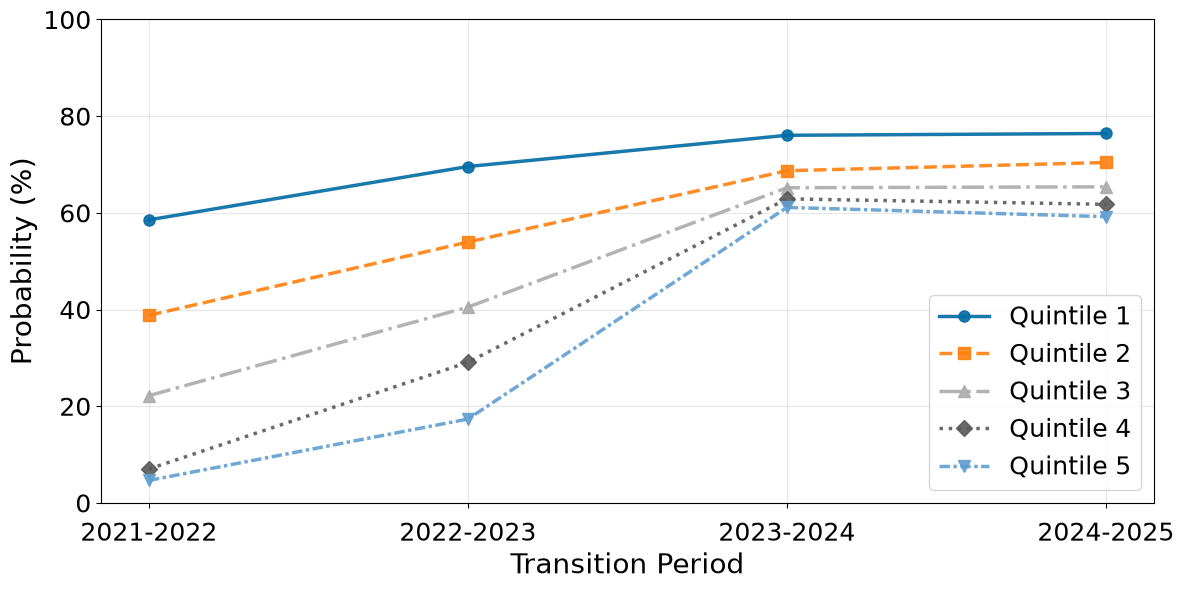

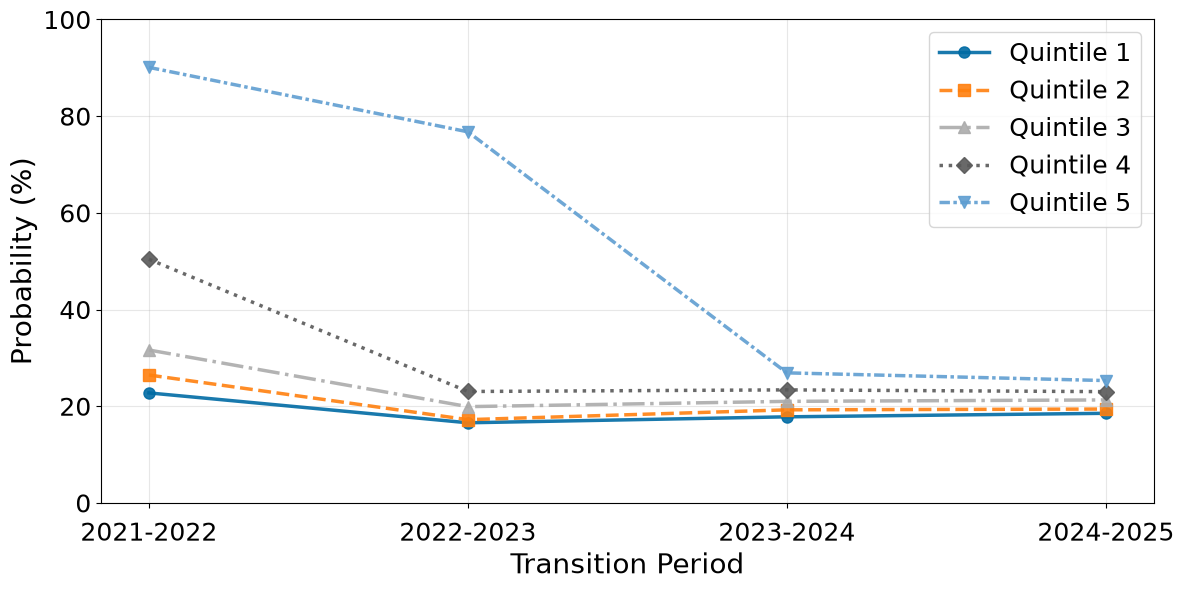

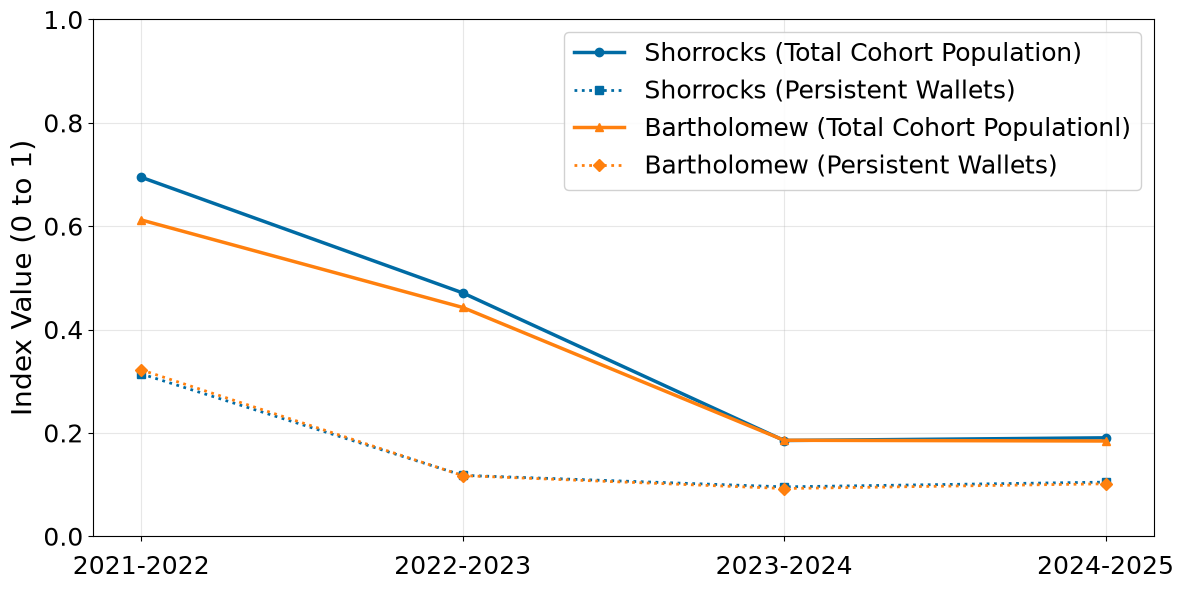

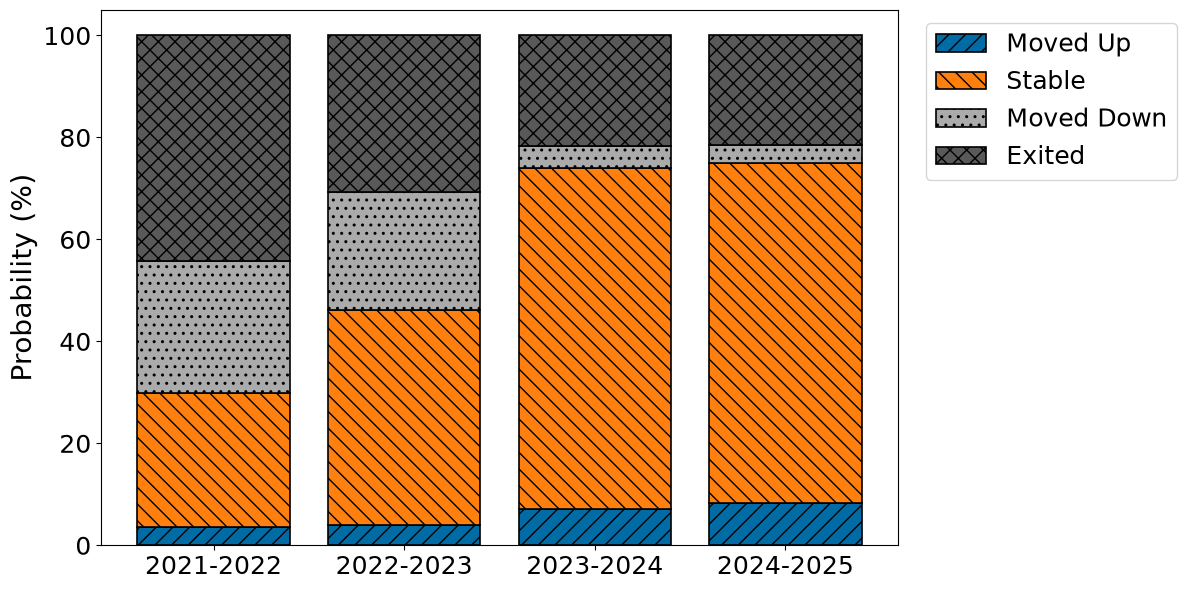

In [23]:
def plot_groups_over_time(df_metric, title, ylabel):
    plt.figure(figsize=(12, 6))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    markers = ['o', 's', '^', 'D', 'v']
    linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
    
    for i, group_idx in enumerate(df_metric.index):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]
        group_name = f'Quintile {int(group_idx) + 1}'
        plt.plot(df_metric.columns, df_metric.loc[group_idx], 
                 color=color, marker=marker, linestyle=linestyle, 
                 label=group_name, alpha=0.9, linewidth=2.5, markersize=8)

    #plt.title(title)
    plt.xlabel("Transition Period")
    plt.ylabel(ylabel)
    plt.ylim(0, 100)
    plt.tick_params(axis='x', pad=10)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_mobility_indices(stats):
    """Plot 1: Shorrocks vs Bartholomew indices."""
    labels = stats['labels']
    fig, ax1 = plt.subplots(figsize=(12, 6))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    ax1.plot(labels, stats['shorrocks'], color=colors[0], linestyle='-', marker='o', linewidth=2.5, label="Shorrocks (Total Cohort Population)")
    ax1.plot(labels, stats['shorrocks_survivors'], color=colors[0], linestyle=':', marker='s', linewidth=2, label="Shorrocks (Persistent Wallets)")
    ax1.plot(labels, stats['bartholomew'], color=colors[1], linestyle='-', marker='^', linewidth=2.5, label="Bartholomew (Total Cohort Populationl)")
    ax1.plot(labels, stats['bartholomew_surv'], color=colors[1], linestyle=':', marker='D', linewidth=2, label="Bartholomew (Persistent Wallets)")
    ax1.set_ylim(0, 1)
    ax1.set_ylabel("Index Value (0 to 1)", color='black')
    ax1.legend(loc='upper right', framealpha=0.9)
    #plt.title("Shorrocks & Bartholomew Indices Over Time")
    plt.grid(True, alpha=0.3)
    plt.tick_params(axis='x', pad=10)
    plt.tight_layout()
    plt.show()

def plot_population_flows(stats):
    """Plot 2: Population Dynamics & Exits by Quintile."""
    labels = stats['labels']
    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(len(labels))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    bar_colors = colors[:4]
    
    # Textures (hatches) added to allow black-and-white distinguishability while keeping color
    hatches = ['//', '\\\\', '..', 'xx']
    data_groups = [stats['pct_up'], stats['pct_stable'], stats['pct_down'], stats['exits_rate']]
    group_labels = ['Moved Up', 'Stable', 'Moved Down', 'Exited']
    
    for data, col, hatch_pattern, lbl in zip(data_groups, bar_colors, hatches, group_labels):
        ax.bar(labels, data, bottom=bottom, color=col, hatch=hatch_pattern, edgecolor='black', linewidth=1.2, label=lbl)
        bottom += np.array(data)
        
    #ax.set_title("Population Dynamics")
    ax.set_ylabel("Probability (%)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ---------------- Execution: Addressable Data (Total Filtered) -----------------
addressable_df_same = pd.read_csv("Results/mobility_addressable_same.csv")
addressable_df_exit = pd.read_csv("Results/mobility_addressable_exit.csv")
addressable_stats = pd.read_csv("Results/mobility_addressable_stats.csv")

plot_groups_over_time(addressable_df_same, "[Addressable] Probability to Stay in Same Quintile", "Probability (%)")
plot_groups_over_time(addressable_df_exit, "[Addressable] Probability to Exit the Dataset", "Probability (%)")
plot_mobility_indices(addressable_stats)
plot_population_flows(addressable_stats)

# Mobility - Artemis ETH Filtered (Figures 17-19)

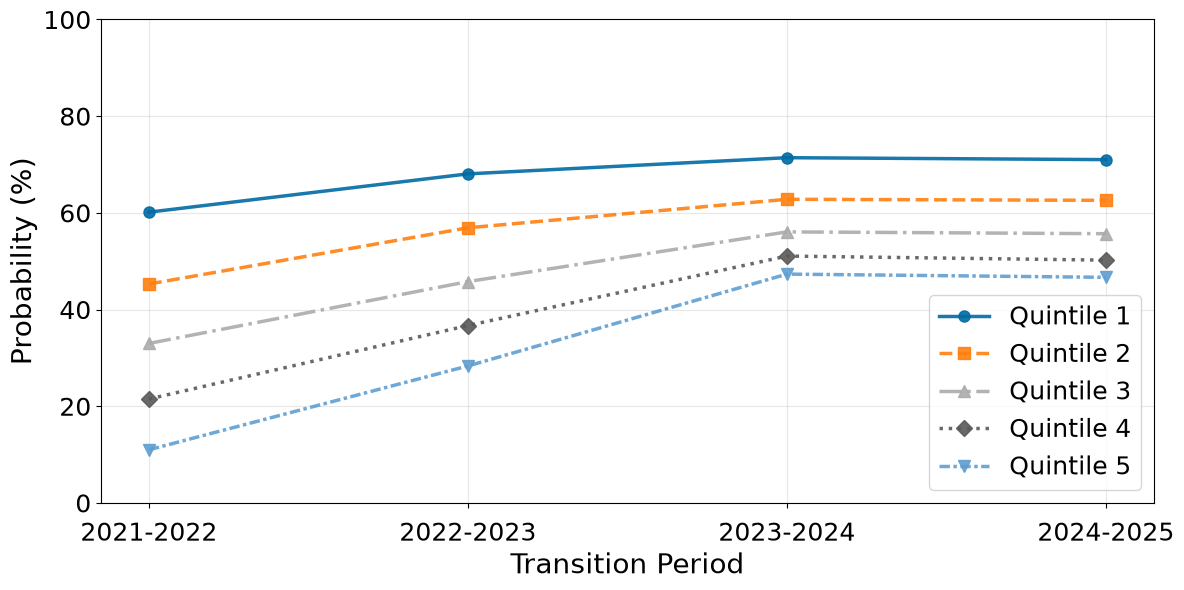

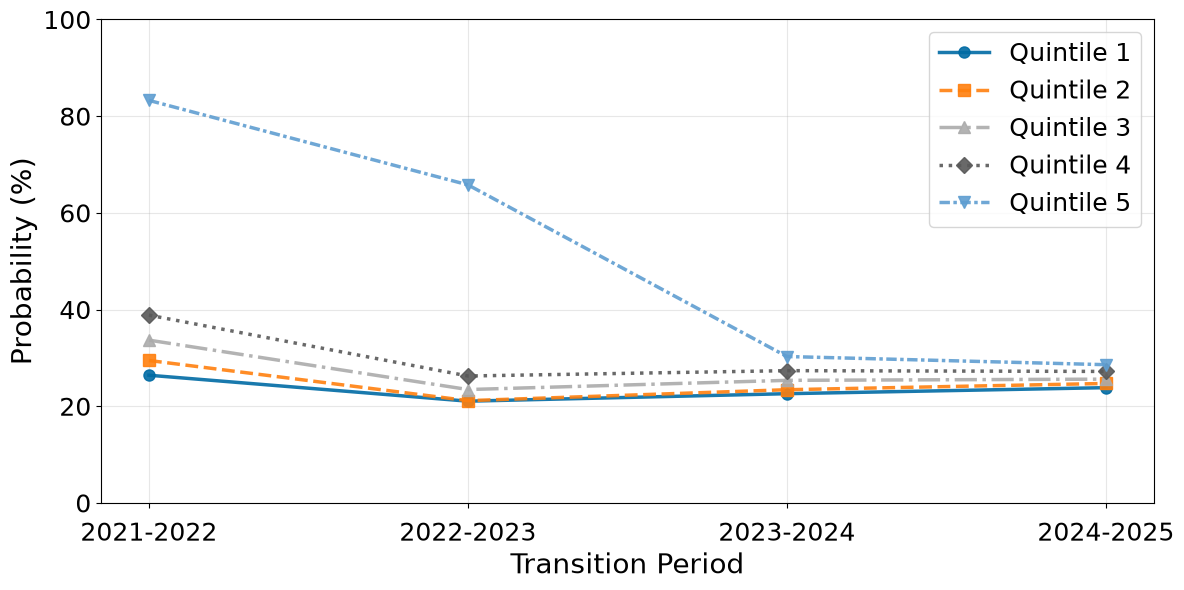

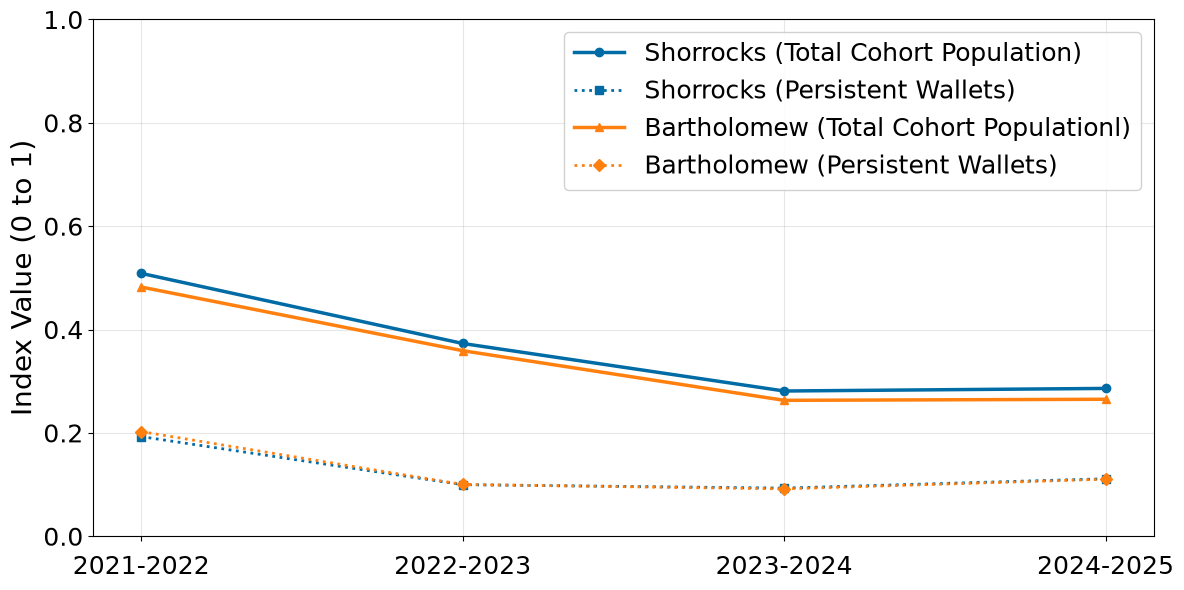

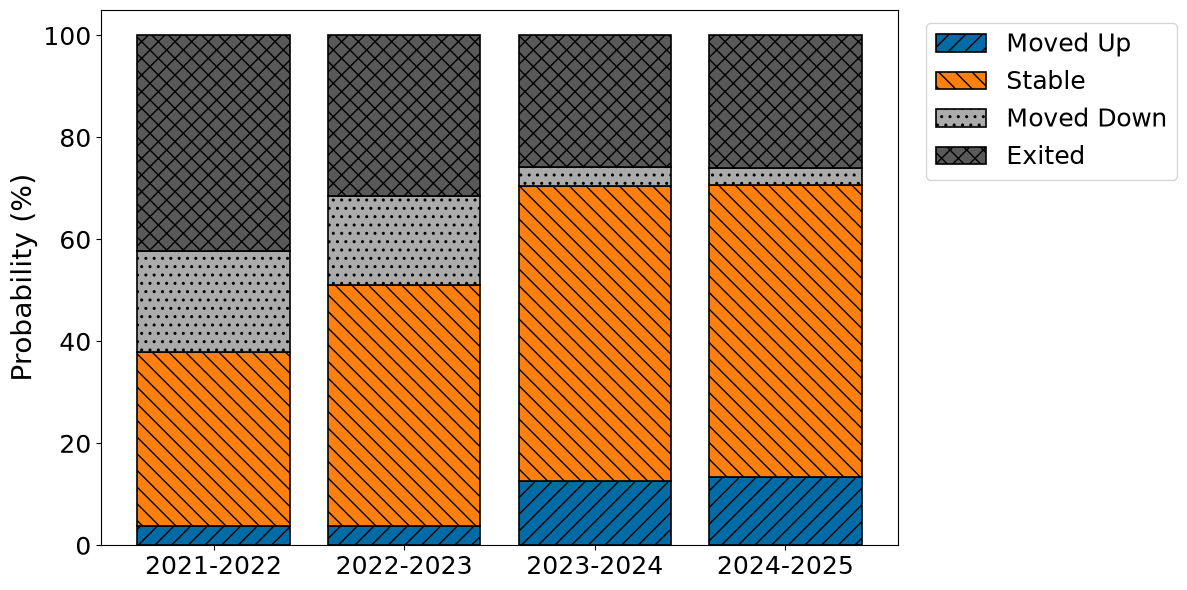

In [24]:
#  Execution: Artemis Data (Filtered)
artemis_df_same = pd.read_csv("Results/mobility_artemis_same.csv")
artemis_df_exit = pd.read_csv("Results/mobility_artemis_exit.csv")
artemis_stats = pd.read_csv("Results/mobility_artemis_stats.csv")

plot_groups_over_time(artemis_df_same, "[Artemis] Probability to Stay in Same Quintile", "Probability (%)")
plot_groups_over_time(artemis_df_exit, "[Artemis] Probability to Exit the Dataset", "Probability (%)")
plot_mobility_indices(artemis_stats)
plot_population_flows(artemis_stats)